In [107]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import glob
import getpass
import act
import pandas as pd
import scipy.spatial as ss
import matplotlib.colors as colors
import seaborn as sns
import scipy.stats as stats

In [2]:
# Check for env variables, otherwise set your username and token here!
# This cell's contents are taken from the summer school ACT notebook
if "ARM_USERNAME" in os.environ:
    arm_username = os.getenv("ARM_USERNAME")
else:
    arm_username = input("Enter ARM username: ").strip()
if "ARM_TOKEN" in os.environ:
    arm_token = os.getenv("ARM_TOKEN")
else:
    arm_token = getpass.getpass("Enter ARM token (hidden): ").strip()

# Set the datastream and start/enddates
cf_datastream = 'sgpaosnanosmpsE13.b1'

startdate = '2023-01-01'
enddate = '2024-01-01'

# Use ACT to easily download the data.  Watch for the data citation!  Show some support
# for ARM's instrument experts and cite their data if you use it in a publication
result_cf_met = act.discovery.download_arm_data(arm_username, arm_token, cf_datastream, startdate, enddate)

Enter ARM username:  aogary
Enter ARM token (hidden):  ········


[DOWNLOADING] sgpaosnanosmpsE13.b1.20230117.214500.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230118.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230119.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230120.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230121.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230122.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230123.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230124.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230125.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230126.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230127.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230128.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230129.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230130.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230131.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230201.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230202.000000.nc
[DOWNLOADING] sgpaosnanosmpsE13.b1.20230203.000000.nc
[DOWNLOADING] sgpaosnanosmps

NameError: name 'ef_datastream' is not defined

In [3]:
# Making a dataset with ACT
ds_cf_met = act.io.read_arm_netcdf(result_cf_met)

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed


In [8]:
# Checking it out
ds_cf_met

<xarray.Dataset> Size: 617MB
Dimensions:                                     (time: 96719, bound: 2,
                                                 diameter_mobility: 192)
Coordinates:
  * time                                        (time) datetime64[ns] 774kB 2...
  * diameter_mobility                           (diameter_mobility) float32 768B ...
Dimensions without coordinates: bound
Data variables: (12/50)
    base_time                                   (time) datetime64[ns] 774kB 2...
    time_offset                                 (time) datetime64[ns] 774kB 2...
    time_bounds                                 (time, bound) object 2MB dask.array<chunksize=(27, 2), meta=np.ndarray>
    diameter_mobility_bounds                    (time, diameter_mobility, bound) float32 149MB dask.array<chunksize=(27, 192, 2), meta=np.ndarray>
    lower_size                                  (time) float32 387kB dask.array<chunksize=(27,), meta=np.ndarray>
    dN_dlogDp                                   (time, diameter_mobility) float32 74MB dask.array<chunksize=(27, 192), meta=np.ndarray>
    ...                                          ...
    DMA_inner_radius                            (time) float32 387kB 0.937 .....
    DMA_outer_radius                            (time) float32 387kB 1.905 .....
    DMA_characteristic_length                   (time) float32 387kB 4.987 .....
    lat                                         (time) float32 387kB 36.6 ......
    lon                                         (time) float32 387kB -97.49 ....
    alt                                         (time) float32 387kB 318.0 .....
Attributes: (12/33)
    command_line:                 aosnanosmpscorr -s sgp -f E13
    Conventions:                  ARM-1.2
    process_version:              ingest-aosnanosmpscorr-1.0-0.el7
    dod_version:                  aosnanosmps-b1-1.0
    site_id:                      sgp
    platform_id:                  aosnanosmps
    ...                           ...
    doi:                          10.5439/1635016
    history:                      created by user dsmgr on machine prod-proc3...
    _file_dates:                  ['20230117', '20230118', '20230119', '20230...
    _file_times:                  ['214500', '000000', '000000', '000000', '0...
    _datastream:                  sgpaosnanosmpsE13.b1
    _arm_standards_flag:          1

In [9]:
# Cleaning up the data
ds_cf_met.clean.cleanup()

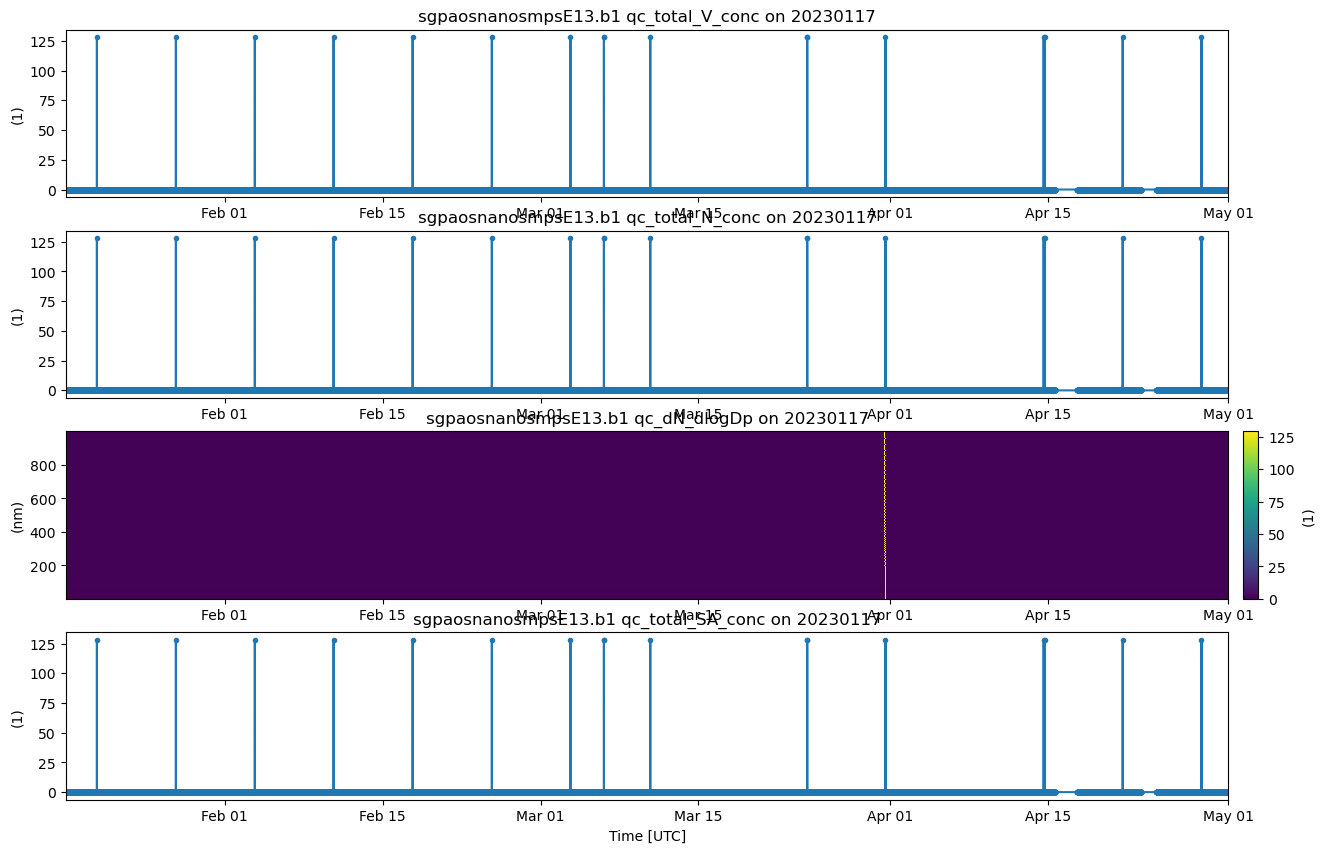

In [63]:
# Choose variables to plot
variable = 'qc_total_V_conc'
qc1 = 'qc_total_N_conc'
qc2 = 'qc_dN_dlogDp'
qc3 = 'qc_total_SA_conc'
geom = 'geometric_mean'
size_dist = 'dN_dlogDp'
geom_std = 'geometric_std'

# Plot the quality control variables to see if they're all on the same day
display = act.plotting.TimeSeriesDisplay(ds_cf_met.sel(time=slice('2023-05-20T00:00', '2023-05-23T00:00')), figsize=(15, 10), subplot_shape=(4,))
display.plot(variable, subplot_index=(0,))
display.plot(qc1, subplot_index=(1,))
display.plot(qc2, subplot_index=(2,))
display.plot(qc3, subplot_index=(3,))
#display.qc_flag_block_plot(variable, subplot_index=(1,))
plt.show()

## Plans: ##
_First Steps:_
Selecting the good data = when >260 time stamps are available per day, because that's over 90% of the day with good data (288 5-minute time stamps in a day). This is because one of the main parameters we use for the model is the mean geometric diameter averaged over an entire day, so if the day only has a couple datapoints, that averaged geometric diameter value could be quite different from the others, and confuse the model.

Take out timestamps that have any qc errors, add up the remaining timestamps per day, if it's still greater than 260, good. 

Make sure using local time, so subtracting 6 hours from the data!

After all the bad dates are taken out, take the average of the geometric mean diameter over an entire day

Also extract the IQR - get the 25th percentile and the 75th percentile. So should have 4 params: day, mean over the day, 25th percentile throughout the day, 75th percentile throughout the day

In [20]:
# See how many timesteps there are (5-min intervals)
len(ds_cf_met.time_bounds)

96719

In [59]:
# Starting manual cleaning methods because qc flags continue
# Choosing one file to check the methods with before making a loop
file1 = 'sgpaosnanosmpsE13.b1/sgpaosnanosmpsE13.b1.20230303.000000.nc'
directory = glob.glob('sgpaosnanosmpsE13.b1/*.nc')

# QC names:
# qc_dN_dlogDp ; qc_total_N_conc ; qc_total_SA_conc ; qc_total_V_conc

# Opening the file, finding how many time steps there are
f = xr.open_dataset(file1, engine='netcdf4')
print(len(f.geometric_mean))

# Looking at the value of error flags
print(np.max(f.qc_dN_dlogDp.values), np.max(f.qc_total_N_conc.values), np.max(f.qc_total_SA_conc.values), np.max(f.qc_total_V_conc.values))

# Plan: make those with bad QC flags nan, then loop through and see if the total time stamps - the bad qcs are still greater than 260. 
# Testing some things (unnecessary for running!)
f2 = f.where(f.qc_total_V_conc == 0, drop=True)
print(len(f2.qc_total_V_conc), len(f.qc_total_V_conc))
f3 = f.isel(time=(f.qc_total_V_conc==0))
print(len(f.qc_total_V_conc), len(f2.qc_total_V_conc),len(f3.qc_total_V_conc))


288
129 128 128 128
287 288
288 287 287


In [60]:
# Testing daily loop (not necessary for final run)
goodlist = []  # produces a list of files (days) with enough data
badlist = []   # produces a list of files (days) with not enough data
for file in directory:
    f = xr.open_dataset(file, engine='netcdf4')  # open each daily file
    if (len(f.geometric_mean) >= 260):    # only choose days with enough data to not mess up the mean
        #print(file,'bad')
        goodlist.append(file)
    if (len(f.geometric_mean) < 260):
        badlist.append(file)              
print(len(goodlist),len(badlist))


325 22


In [61]:
# Testing qc loop (not necessary for final run)
#   --- can just use 1, double-checked and they occur at the same times in all 4 qc variables
qc = f.qc_dN_dlogDp.values

for file in directory:
    f = xr.open_dataset(file, engine='netcdf4')
    print(len(f.geometric_mean))
    f2 = f.isel(time=(f.qc_total_V_conc==0))  # only choosing timestamps with no qc flags, dropping those that do
    print(len(f2.geometric_mean),'next \n')   # printed again to see the difference in timestamps after qc flagged data are taken out


288
288 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

277
277 next 

288
288 next 

288
0 next 

120
118 next 

288
287 next 

288
288 next 

110
110 next 

288
288 next 

288
288 next 

288
287 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

288
287 next 

288
288 next 

288
287 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

288
287 next 

12
12 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

287
287 next 

288
288 next 

288
288 next 

288
287 next 

288
287 next 

288
288 next 

288
288 next 

288
287 next 

180
180 next 

288
288 next 

288
288 next 

288
288 next 

289
289 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

288
288 next 

166
166 next 

288
286 next 

288
288 next 

288
288 next 

288
288 next 

288
287 next 


In [109]:
#  ---  Combining the two loops into one for the perfect cleaned dataset  ---
goodlist = []
badlist = []
for file in directory:
    f = xr.open_dataset(file, engine='netcdf4')
    f2 = f.isel(time=(f.qc_total_V_conc==0))
    if (len(f2.geometric_mean) >= 260):
        goodlist.append(file)
    if (len(f2.geometric_mean) < 260):
        badlist.append(file)
print(len(goodlist),len(badlist))  # first sorts into dates (files) that have enough data to start with

# Using the goodlist to select the good data files after qc flagged data removal
print(goodlist[0:3]) # just to see an example of good files
dslist = []
for file in goodlist:
    f = xr.open_dataset(file, engine='netcdf4')
    good = f.qc_total_V_conc==0     # making a smaller selection where no qc flagged data
    f2 = f.where(good, drop=True)
    f2 = f2.where((f.geometric_mean>0) & (f.geometric_mean!= -1), drop=True)  # gets rid of some weird unflagged data (manual cleaning)
    dslist.append(f2)
ds = xr.concat(dslist, dim='time').sortby('time')  # combine the data into one good, clean dataset, making sure it's sorted in ascending time
print(ds.time.values)

317 30
['sgpaosnanosmpsE13.b1/sgpaosnanosmpsE13.b1.20230702.000000.nc', 'sgpaosnanosmpsE13.b1/sgpaosnanosmpsE13.b1.20231125.000000.nc', 'sgpaosnanosmpsE13.b1/sgpaosnanosmpsE13.b1.20230802.000000.nc']
['2023-01-18T00:00:00.000000000' '2023-01-18T00:05:00.000000000'
 '2023-01-18T00:10:00.000000000' ... '2023-12-30T23:45:00.000000000'
 '2023-12-30T23:50:01.000000000' '2023-12-30T23:55:00.000000000']


In [41]:
# Just checking some values (unnecessary)
print((ds.geometric_mean==0).sum().values)
print(ds.geometric_mean.min().values)
print(ds.geometric_mean.attrs)

0
4.7829999923706055
{'long_name': 'Mean diameter of size distribution using a geometric average', 'units': 'nm', 'comment': 'Geometric mean of the size distribution'}


_Reiterating plans:_

Generating the mean geometric diameter over each day

Looking at the 25th and 75th percentile range as well - should be changing similarly

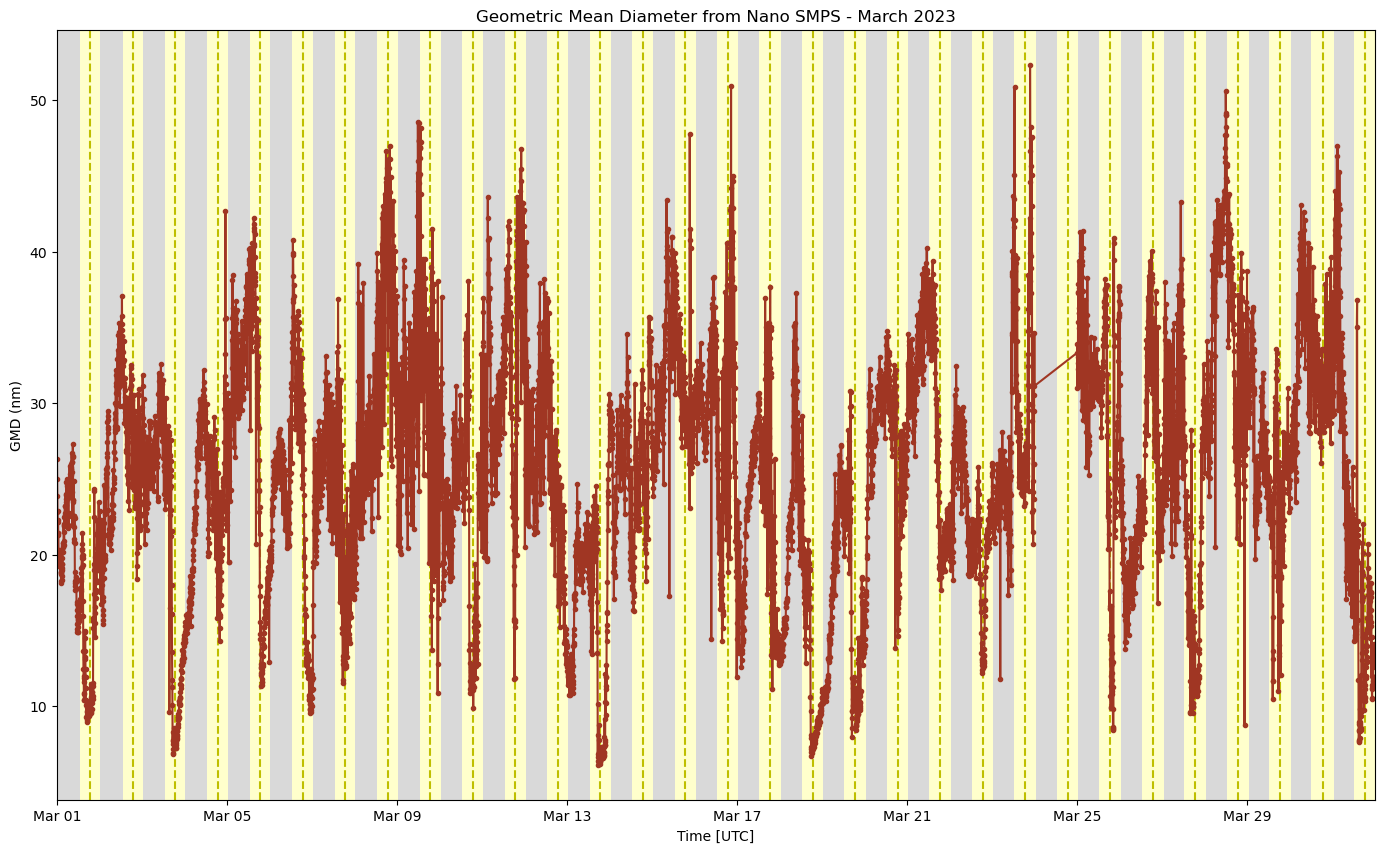

In [46]:
# Creating a time series plot for a single month by using ACT package

display = act.plotting.TimeSeriesDisplay({'mar':ds.sel(time='2023-03')}, figsize=(17, 10))
display.plot('geometric_mean', dsname='mar', subplot_index=(0,), set_title='Geometric Mean Diameter from Nano SMPS - March 2023',
             ylabel='GMD (nm)', color='xkcd:brick')
display.day_night_background(dsname='mar')

In [110]:
# TIME CONVERSION THAT'S A LITTLE STRANGE! USE THE NEXT CELL INSTEAD! 
# Converting from UTC to local time (central standard, not using daylight) by adding an attribute
ds['local_time'] = ds['time'] - pd.Timedelta(hours=6)
ds['local_time'].attrs['note'] = 'UTC time minus 6, Central Standard Time'

# Making sure that the new column works
print(ds.time.values[0:2])
print(ds.local_time.values[0:2])

# Plotting March again to see if there's a difference (let's hope so)
#display = act.plotting.TimeSeriesDisplay({'mar_local':local_ds.sel(time='2023-03')}, figsize=(17, 10))
#display.plot('geometric_mean', dsname='mar_local', subplot_index=(0,), set_title='Geometric Mean Diameter from Nano SMPS - March 2023',
#             ylabel='GMD (nm)', color='xkcd:brick')
#display.day_night_background(dsname='mar_local')

['2023-01-18T00:00:00.000000000' '2023-01-18T00:05:00.000000000']
['2023-01-17T18:00:00.000000000' '2023-01-17T18:05:00.000000000']


In [157]:
# Finding the average of geometric diameters per day, as well as the variance, 25th 75th quartiles
ds_local = ds.copy()
ds_local['time'] = ds_local['time'] - pd.Timedelta(hours=6)  # convert to CST time instead of UTC

# Sort per single days, then find the mean, 25th, and 75th percentile of geometric mean diameter per day (one value of each per day)
group = ds_local['geometric_mean'].groupby('time.date')
daily_mean = group.mean()
daily_25 = group.quantile(0.25)
daily_75 = group.quantile(0.75)

# Trying to fix the plotting (ultimately didn't fix...)
daily_mean = daily_mean.assign_coords(date=pd.to_datetime(daily_mean['date']))
daily_25 = daily_25.assign_coords(date=pd.to_datetime(daily_25['date']))
daily_75 = daily_75.assign_coords(date=pd.to_datetime(daily_75['date']))

# Checking one day's particular averaged GMD value
print(daily_mean.sel(date='2023-01-18').values)

['2023-01-17T18:00:00.000000000' '2023-01-17T18:05:00.000000000'
 '2023-01-17T18:10:00.000000000' ... '2023-12-30T17:45:00.000000000'
 '2023-12-30T17:50:01.000000000' '2023-12-30T17:55:00.000000000']
22.97992706298828


In [143]:
# Making sure the coordinates are good for plotting the mean / quantiles
daily_mean = daily_mean.assign_coords(date=pd.to_datetime(daily_mean['date']))
print(daily_mean.attrs)

{'long_name': 'Mean diameter of size distribution using a geometric average', 'units': 'nm', 'comment': 'Geometric mean of the size distribution'}


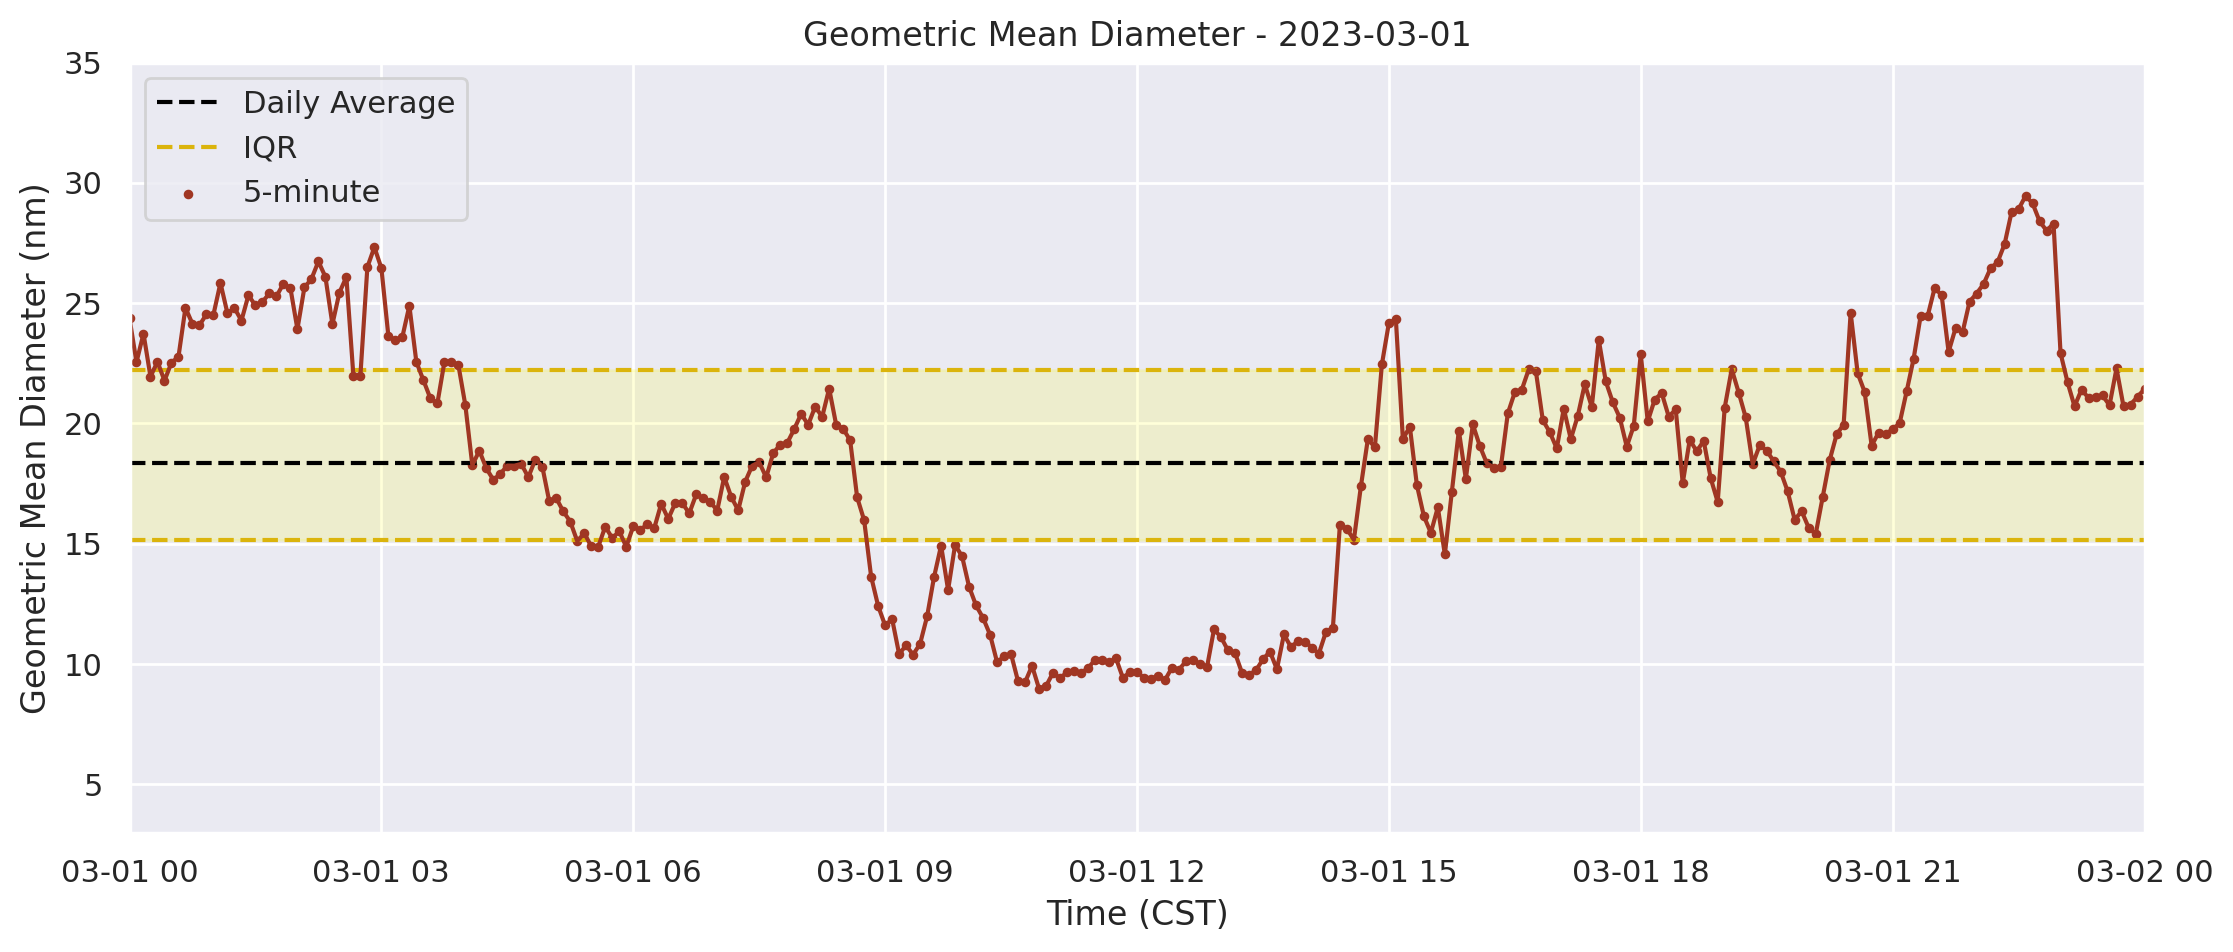

Difference between 75th percentile and mean: 3.84
Difference between 25th percentile and mean: 3.22


In [202]:
# -------------------------------------------------

#      ---     Plotting a specific day     ---

# -------------------------------------------------
# Change inputs below depending on the day chosen! 
day = '2023-03-01'

# Calculating the mean, 25th per, and 75th per for that day
mean = daily_mean.sel(date=day).values
p25 = daily_25.sel(date=day).values
p75 = daily_75.sel(date=day).values

# Plotting
plot = sns.set(style='darkgrid')
plt.rcParams['figure.figsize'] = [13,5]
plt.rcParams['figure.dpi'] = 200
plt.axhspan(p25, p75, color='yellow', alpha=0.15)
#plt.scatter(ds.time.values, ds.geometric_mean, color="xkcd:brick", label='UTC Time', s=3) 
plt.axhline(y=mean, color='xkcd:black',label='Daily Average',linestyle='dashed')
plt.axhline(y=p25, color='xkcd:gold',label='IQR',linestyle='dashed')
plt.axhline(y=p75, color='xkcd:gold',linestyle='dashed')

plt.scatter(ds.local_time.values, ds.geometric_mean, color="xkcd:brick", label='5-minute', s=6) 
plt.plot(ds.local_time.values, ds.geometric_mean, color='xkcd:brick')

plt.legend()
plt.title('Geometric Mean Diameter - '+day)
plt.xlabel('Time (CST)')
plt.ylabel('Geometric Mean Diameter (nm)')
plt.ylim(3,35)
plt.xlim('2023-03-01','2023-03-02')  # CHANGE HERE FOR SPECIFIC DAYS! For the entire year, use '2023-01-01','2024-01-02'
plt.show()
print('Difference between 75th percentile and mean: '+str(round((p75-mean),2)))
print('Difference between 25th percentile and mean: '+str(round((mean-p25),2)))

In [171]:
# Checking the values for plotting reasons
print(p25,p75,mean)

15.146249771118164 22.206250190734863 18.361656188964844


_Moving forward:_

Use sample_relative_humidity, sample_temperature to look at the surrounding conditions from the sample throughout the day

## Case dates from the trained ML model (from Ruoyu)! Cases that were **false negatives**:
august 21 (actual NPF, but not recognized); aug 27 (actual npf, didn't recognize)
## Cases that were **false positives**:
dec 19 (model said yes, but not really) ; may 21 (model said yes, not actually transported)

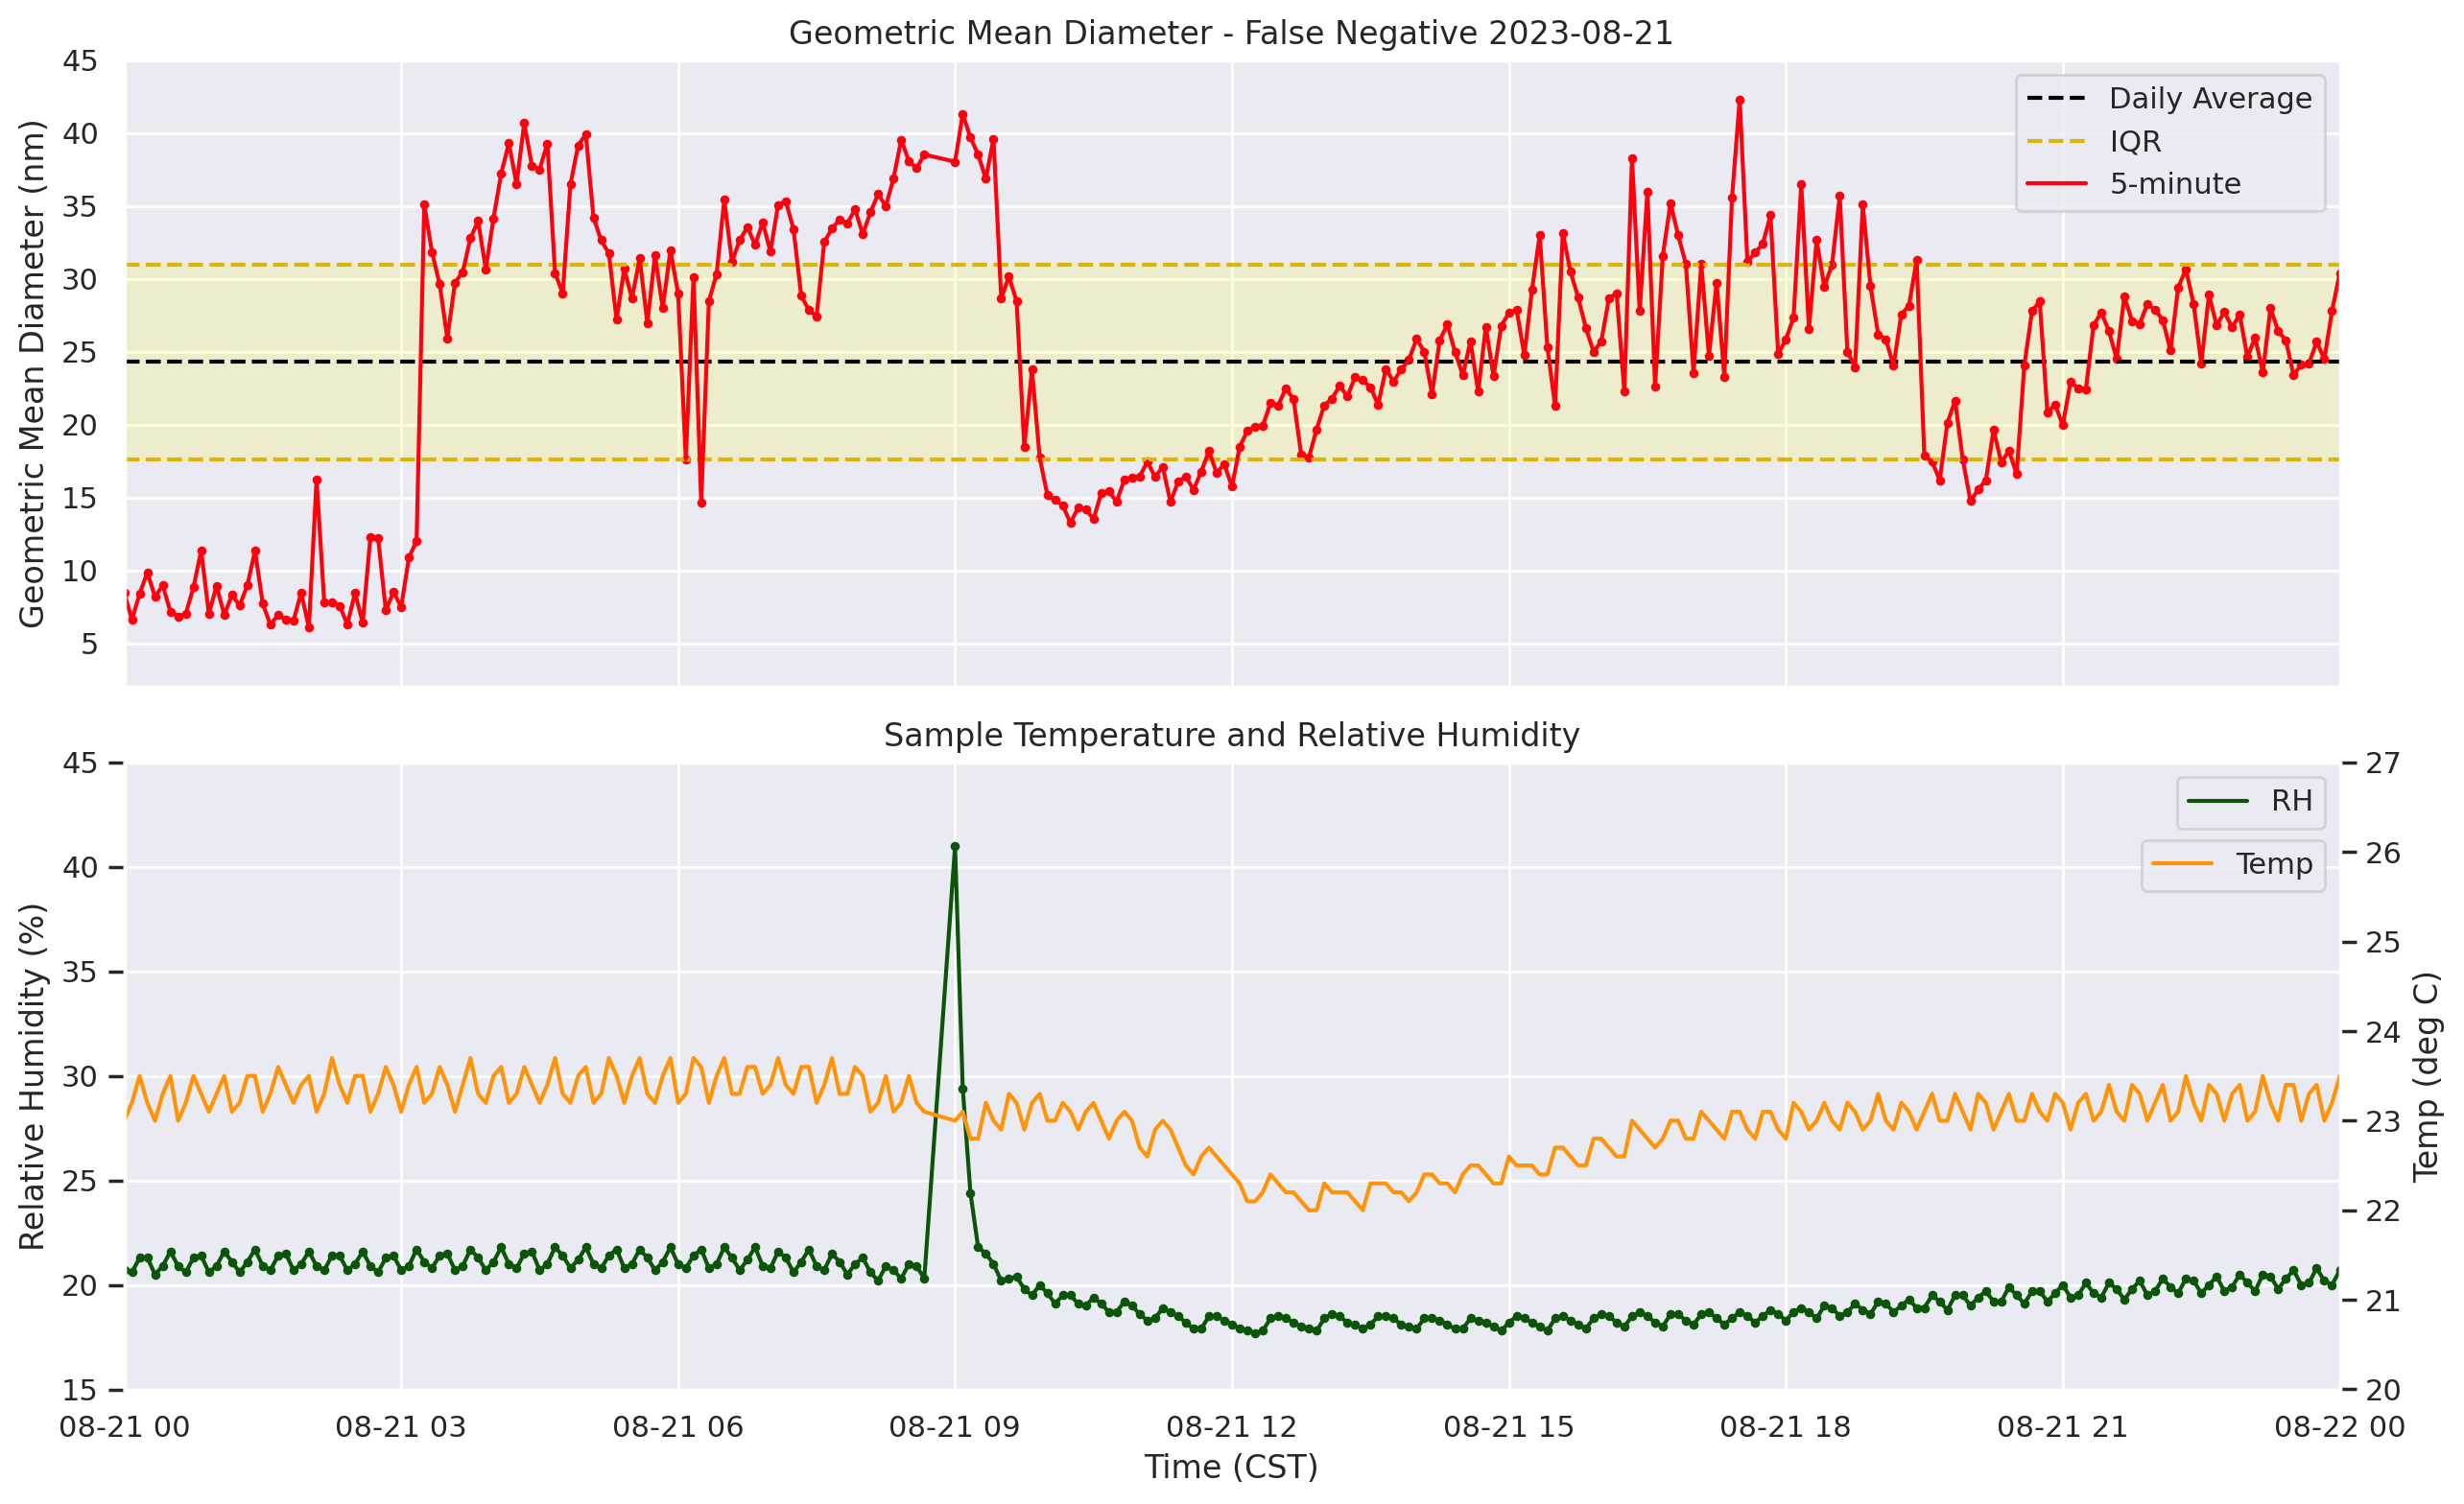

Difference between 75th percentile and mean: 6.67 nm
Difference between 25th percentile and mean: 6.71 nm


In [244]:
# Change inputs below depending on the day chosen!
day = '2023-08-21'

# Calculating daily values to plot
mean = daily_mean.sel(date=day).values
p25 = daily_25.sel(date=day).values
p75 = daily_75.sel(date=day).values

# Plotting
plot = sns.set(style='darkgrid')
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(13,8),dpi=200,sharex=True)

ax1.axhspan(p25, p75, color='yellow', alpha=0.15)
ax1.axhline(y=mean, color='xkcd:black',label='Daily Average',linestyle='dashed')
ax1.axhline(y=p25, color='xkcd:gold',label='IQR',linestyle='dashed')
ax1.axhline(y=p75, color='xkcd:gold',linestyle='dashed')

ax1.scatter(ds.local_time.values, ds.geometric_mean, color="xkcd:bright red", s=6) 
ax1.plot(ds.local_time.values, ds.geometric_mean, color='xkcd:bright red',label='5-minute')

plot = sns.set(style='dark')
ax2.scatter(ds.local_time.values, ds.sample_relative_humidity,color='xkcd:forest',s=6)
ax2.plot(ds.local_time.values, ds.sample_relative_humidity,color='xkcd:forest',label='RH')

ax3 = ax2.twinx()
ax3.plot(ds.local_time.values, ds.sample_temperature,color='xkcd:tangerine',label='Temp')

ax1.legend()
ax1.set_title('Geometric Mean Diameter - False Negative '+day)
ax1.set_ylabel('Geometric Mean Diameter (nm)')
ax1.set_ylim(2,45)
ax1.set_xlim('2023-08-21','2023-08-22')  # CHANGE HERE FOR SPECIFIC DAYS! For the entire year, use '2023-01-01','2024-01-02'

ax2.set_title('Sample Temperature and Relative Humidity')
ax2.set_ylabel('Relative Humidity (%)')
ax2.set_ylim(15, 45)
ax2.set_xlabel('Time (CST)')
ax2.legend(bbox_to_anchor=(1,1))

ax3.set_ylabel('Temp (deg C)')
ax3.set_ylim(20,27)
ax3.legend(bbox_to_anchor=(1,0.90))

plt.tight_layout()
plt.show()
fig.savefig('false_neg_0821.png',dpi=300,bbox_inches='tight')

print('Difference between 75th percentile and mean: '+str(round((p75-mean),2))+' nm')
print('Difference between 25th percentile and mean: '+str(round((mean-p25),2))+' nm')

In [224]:
# Printing to make sure that the units are right - temp is in deg C, RH is in %
print(ds.sample_temperature)

<xarray.DataArray 'sample_temperature' (time: 91079)> Size: 364kB
array([24.1, 24.5, 24.2, ..., 23. , 23.3, 23.5], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 729kB 2023-01-18 ... 2023-12-30T23:55:00
Attributes:
    long_name:  Sample temperature
    units:      degC


Pull up some radar data from the 4 cases and show that too!


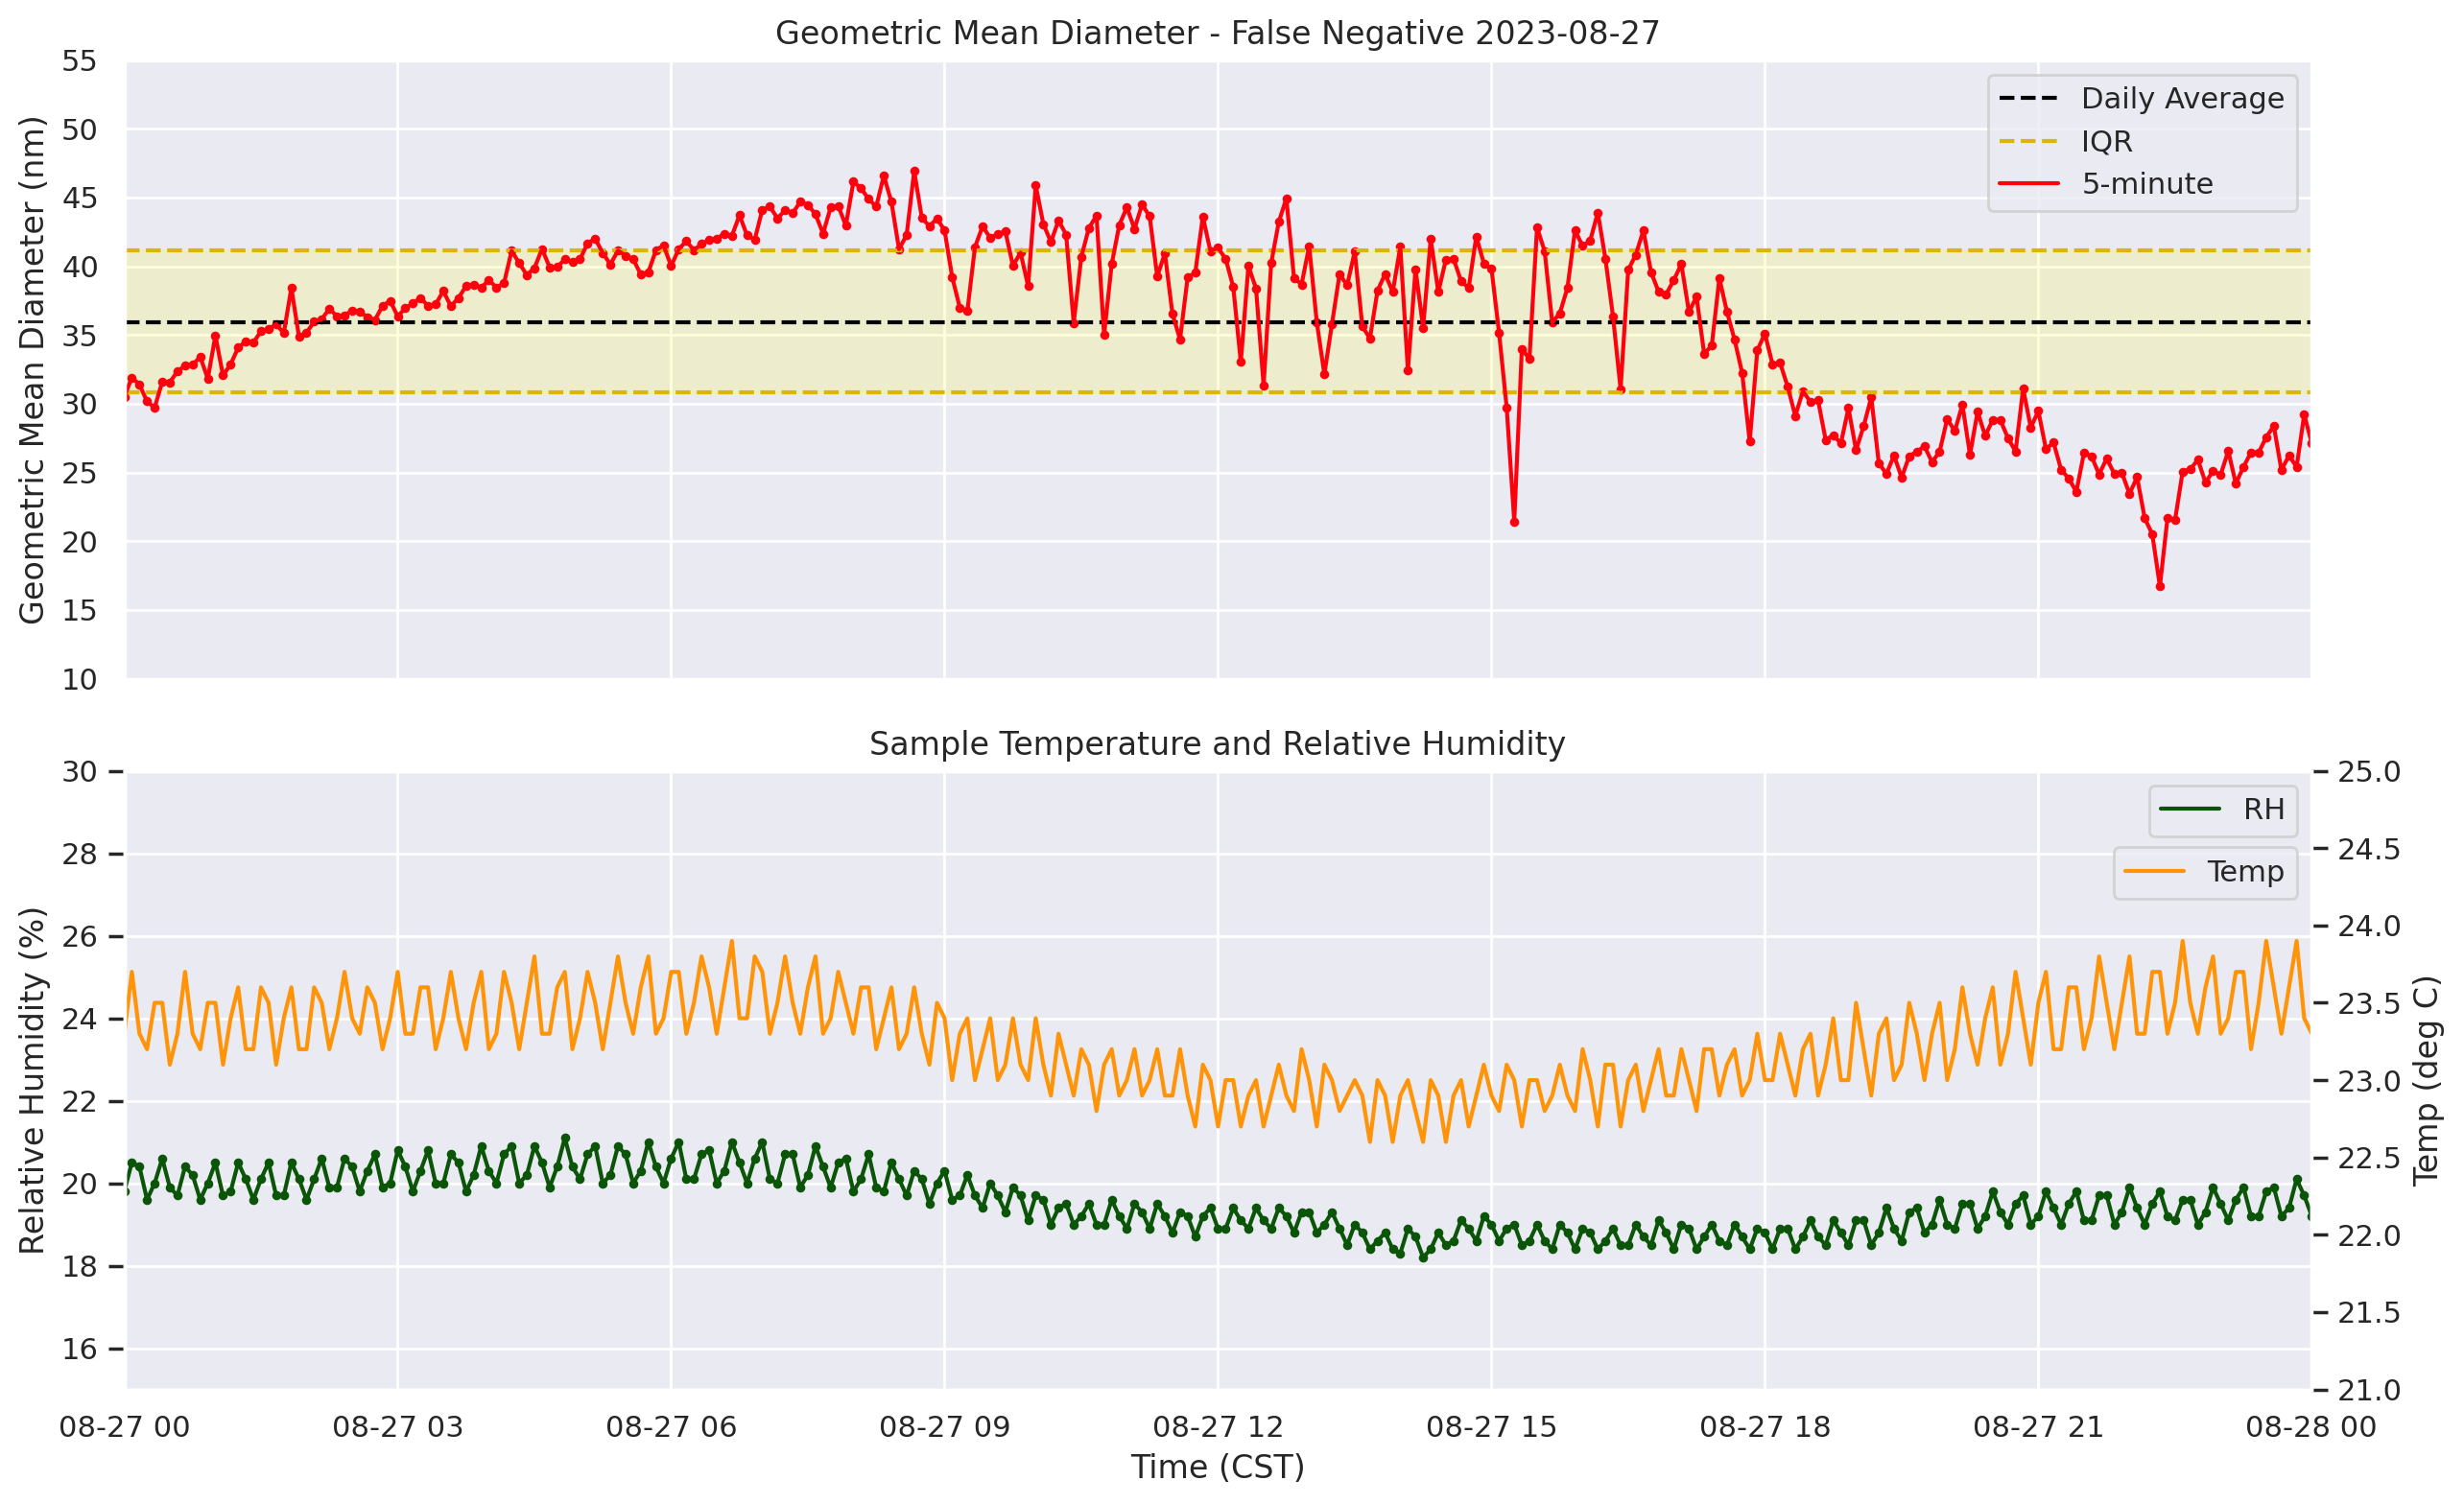

Difference between 75th percentile and mean: 5.25 nm
Difference between 25th percentile and mean: 5.09 nm


In [247]:
# Change inputs below
date_interest = '2023-08-27T00:10:00.000000000'   # Change depending on the day chosen!
day = '2023-08-27'

# Calculating daily values to plot
mean = daily_mean.sel(date=day).values
p25 = daily_25.sel(date=day).values
p75 = daily_75.sel(date=day).values

# Plotting
plot = sns.set(style='darkgrid')
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(13,8),dpi=200,sharex=True)

ax1.axhspan(p25, p75, color='yellow', alpha=0.15)
ax1.axhline(y=mean, color='xkcd:black',label='Daily Average',linestyle='dashed')
ax1.axhline(y=p25, color='xkcd:gold',label='IQR',linestyle='dashed')
ax1.axhline(y=p75, color='xkcd:gold',linestyle='dashed')
ax1.scatter(ds.local_time.values, ds.geometric_mean, color="xkcd:bright red", s=6) 
ax1.plot(ds.local_time.values, ds.geometric_mean, color='xkcd:bright red',label='5-minute')

plot = sns.set(style='dark')
ax2.scatter(ds.local_time.values, ds.sample_relative_humidity,color='xkcd:forest',s=6)
ax2.plot(ds.local_time.values, ds.sample_relative_humidity,color='xkcd:forest',label='RH')
ax3 = ax2.twinx()
ax3.plot(ds.local_time.values, ds.sample_temperature,color='xkcd:tangerine',label='Temp')

ax1.legend()
ax1.set_title('Geometric Mean Diameter - False Negative '+day)
ax1.set_ylabel('Geometric Mean Diameter (nm)')
ax1.set_ylim(10,55)
ax1.set_xlim('2023-08-27','2023-08-28')  # CHANGE HERE FOR SPECIFIC DAYS! For the entire year, use '2023-01-01','2024-01-02'
ax2.set_title('Sample Temperature and Relative Humidity')
ax2.set_ylabel('Relative Humidity (%)')
ax2.set_ylim(15, 30)
ax2.set_xlabel('Time (CST)')
ax2.legend(bbox_to_anchor=(1,1))
ax3.set_ylabel('Temp (deg C)')
ax3.set_ylim(21,25)
ax3.legend(bbox_to_anchor=(1,0.90))

plt.tight_layout()
plt.show()
fig.savefig('false_neg_0827.png',dpi=300,bbox_inches='tight')

print('Difference between 75th percentile and mean: '+str(round((p75-mean),2))+' nm')
print('Difference between 25th percentile and mean: '+str(round((mean-p25),2))+' nm')

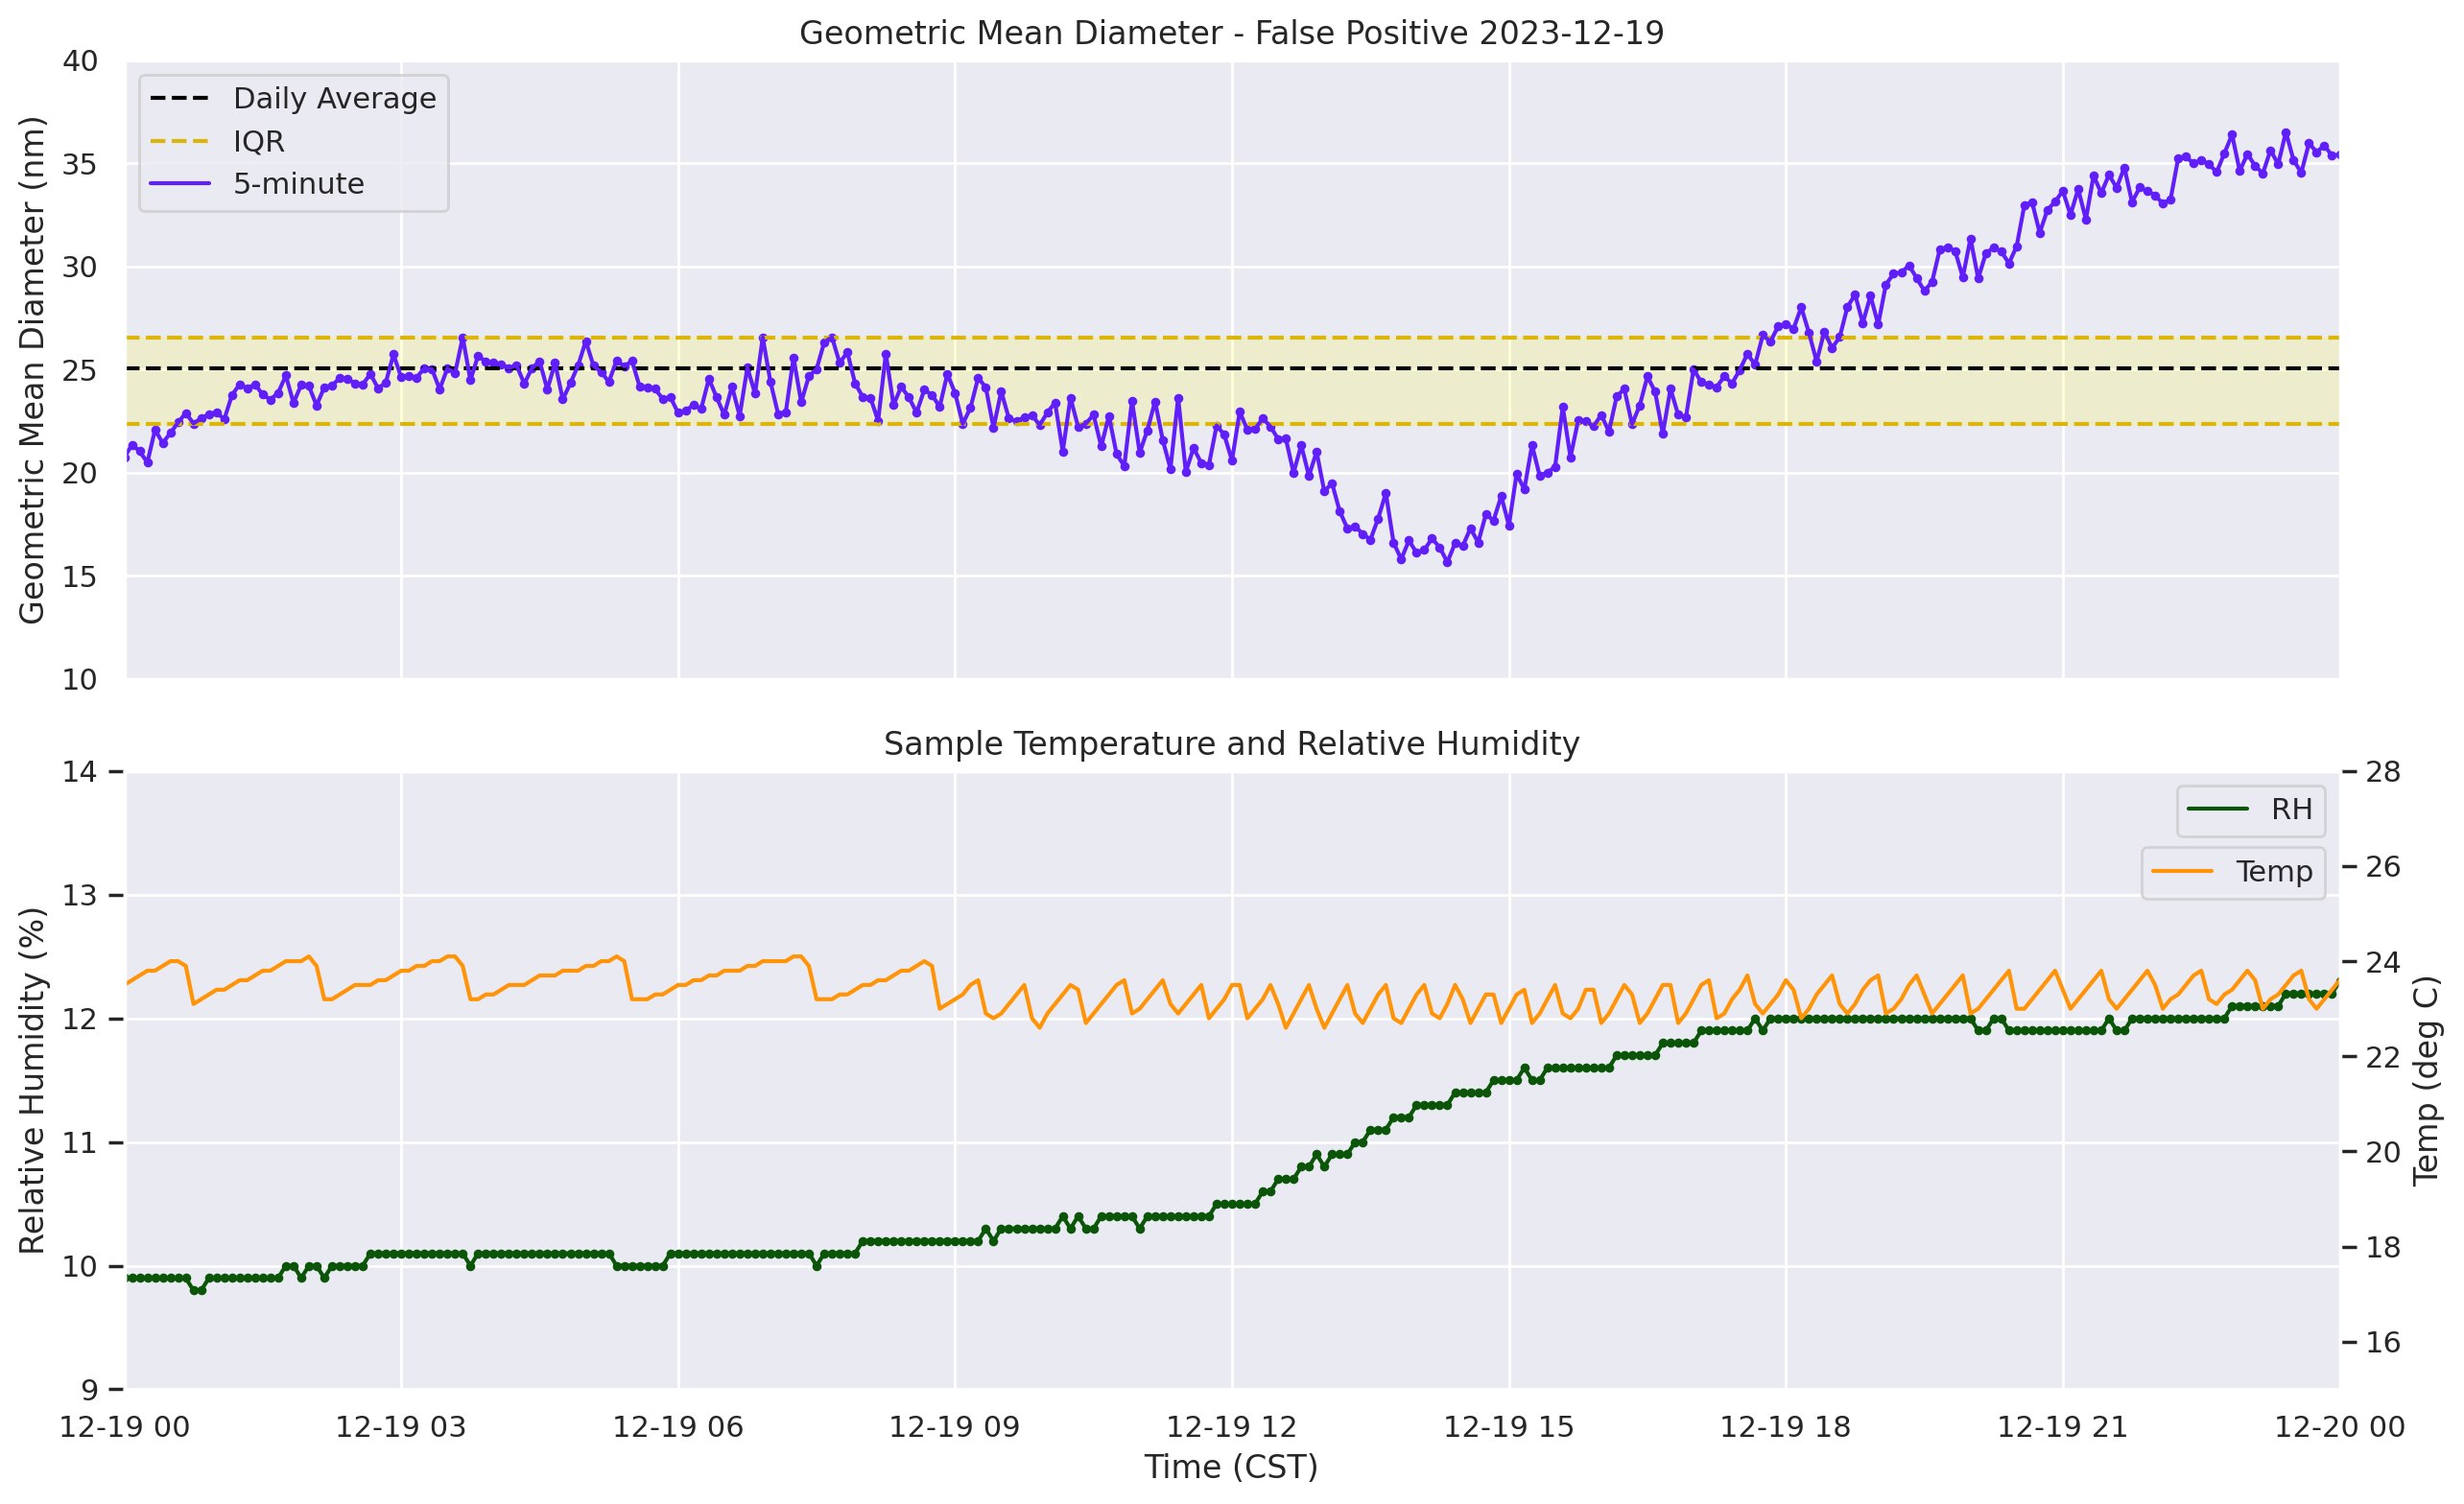

Difference between 75th percentile and mean: 1.53 nm
Difference between 25th percentile and mean: 2.66 nm


In [268]:
# Change inputs below depending on the day chosen!
day = '2023-12-19'

# Calculating daily values to plot
mean = daily_mean.sel(date=day).values
p25 = daily_25.sel(date=day).values
p75 = daily_75.sel(date=day).values

# Plotting
plot = sns.set(style='darkgrid')
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(13,8),dpi=200,sharex=True)

ax1.axhspan(p25, p75, color='yellow', alpha=0.15)
ax1.axhline(y=mean, color='xkcd:black',label='Daily Average',linestyle='dashed')
ax1.axhline(y=p25, color='xkcd:gold',label='IQR',linestyle='dashed')
ax1.axhline(y=p75, color='xkcd:gold',linestyle='dashed')
ax1.scatter(ds.local_time.values, ds.geometric_mean, color="xkcd:purplish blue", s=6) 
ax1.plot(ds.local_time.values, ds.geometric_mean, color='xkcd:purplish blue',label='5-minute')

plot = sns.set(style='dark')
ax2.scatter(ds.local_time.values, ds.sample_relative_humidity,color='xkcd:forest',s=6)
ax2.plot(ds.local_time.values, ds.sample_relative_humidity,color='xkcd:forest',label='RH')
ax3 = ax2.twinx()
ax3.plot(ds.local_time.values, ds.sample_temperature,color='xkcd:tangerine',label='Temp')

ax1.legend()
ax1.set_title('Geometric Mean Diameter - False Positive '+day)
ax1.set_ylabel('Geometric Mean Diameter (nm)')
ax1.set_ylim(10,40)
ax1.set_xlim('2023-12-19','2023-12-20')  # CHANGE HERE FOR SPECIFIC DAYS! For the entire year, use '2023-01-01','2024-01-02'
ax2.set_title('Sample Temperature and Relative Humidity')
ax2.set_ylabel('Relative Humidity (%)')
ax2.set_ylim(9, 14)
ax2.set_xlabel('Time (CST)')
ax2.legend(bbox_to_anchor=(1,1))
ax3.set_ylabel('Temp (deg C)')
ax3.set_ylim(15,28)
ax3.legend(bbox_to_anchor=(1,0.90))

plt.tight_layout()
plt.show()
fig.savefig('false_pos_1219.png',dpi=300,bbox_inches='tight')

print('Difference between 75th percentile and mean: '+str(round((p75-mean),2))+' nm')
print('Difference between 25th percentile and mean: '+str(round((mean-p25),2))+' nm')

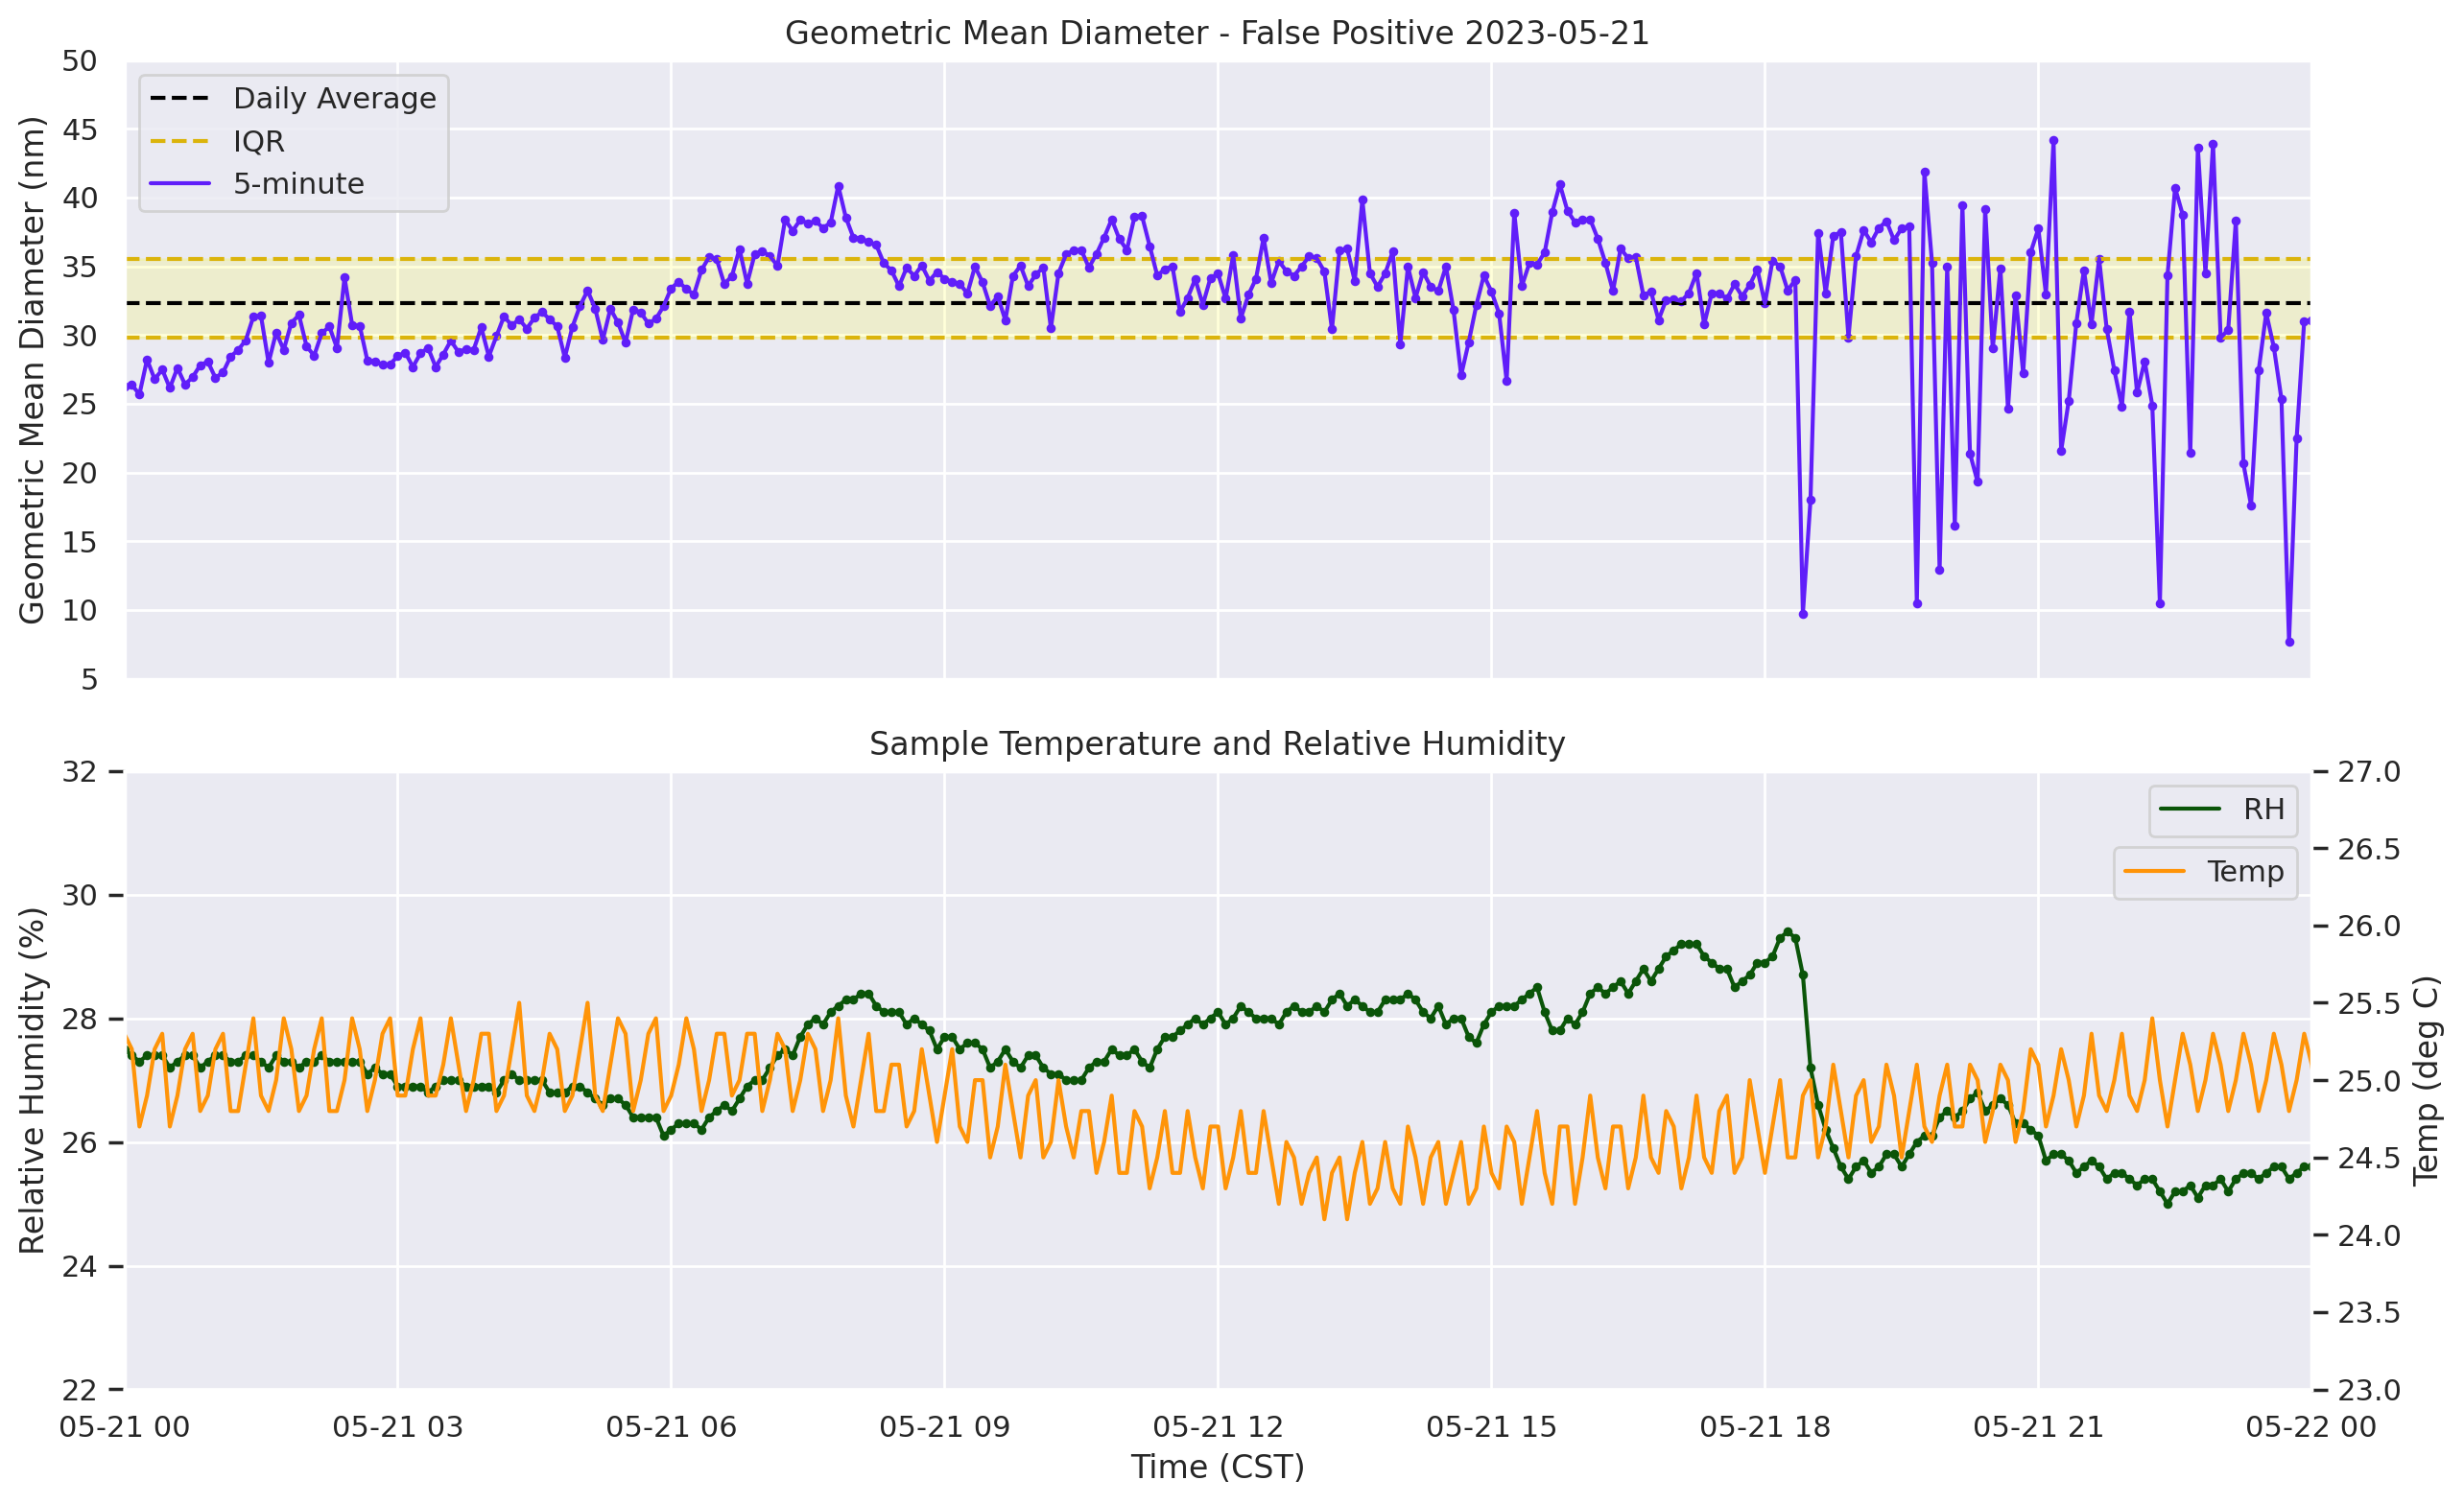

Difference between 75th percentile and mean: 3.17 nm
Difference between 25th percentile and mean: 2.52 nm


In [269]:
# Change inputs below depending on the day chosen!
day = '2023-05-21'

# Calculating daily values to plot
mean = daily_mean.sel(date=day).values
p25 = daily_25.sel(date=day).values
p75 = daily_75.sel(date=day).values

# Plotting
plot = sns.set(style='darkgrid')
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(13,8),dpi=200,sharex=True)

ax1.axhspan(p25, p75, color='yellow', alpha=0.15)
ax1.axhline(y=mean, color='xkcd:black',label='Daily Average',linestyle='dashed')
ax1.axhline(y=p25, color='xkcd:gold',label='IQR',linestyle='dashed')
ax1.axhline(y=p75, color='xkcd:gold',linestyle='dashed')
ax1.scatter(ds.local_time.values, ds.geometric_mean, color="xkcd:purplish blue", s=6) 
ax1.plot(ds.local_time.values, ds.geometric_mean, color='xkcd:purplish blue',label='5-minute')

plot = sns.set(style='dark')
ax2.scatter(ds.local_time.values, ds.sample_relative_humidity,color='xkcd:forest',s=6)
ax2.plot(ds.local_time.values, ds.sample_relative_humidity,color='xkcd:forest',label='RH')
ax3 = ax2.twinx()
ax3.plot(ds.local_time.values, ds.sample_temperature,color='xkcd:tangerine',label='Temp')

ax1.legend()
ax1.set_title('Geometric Mean Diameter - False Positive '+day)
ax1.set_ylabel('Geometric Mean Diameter (nm)')
ax1.set_ylim(5,50)
ax1.set_xlim('2023-05-21','2023-05-22')  # CHANGE HERE FOR SPECIFIC DAYS! For the entire year, use '2023-01-01','2024-01-02'
ax2.set_title('Sample Temperature and Relative Humidity')
ax2.set_ylabel('Relative Humidity (%)')
ax2.set_ylim(22, 32)
ax2.set_xlabel('Time (CST)')
ax2.legend(bbox_to_anchor=(1,1))
ax3.set_ylabel('Temp (deg C)')
ax3.set_ylim(23,27)
ax3.legend(bbox_to_anchor=(1,0.90))

plt.tight_layout()
plt.show()
fig.savefig('false_pos_0521.png',dpi=300,bbox_inches='tight')

print('Difference between 75th percentile and mean: '+str(round((p75-mean),2))+' nm')
print('Difference between 25th percentile and mean: '+str(round((mean-p25),2))+' nm')

That's all! :)